# Netflix Content Trends

**Business question:** How has Netflix's content strategy shifted over time?

Dataset: [Netflix Movies and TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows)

Before running: download the CSV per `data/README.md` and place it at `data/netflix_titles.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('data/netflix_titles.csv')
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df.shape

(8807, 13)

## 1. Movies vs. TV shows over time

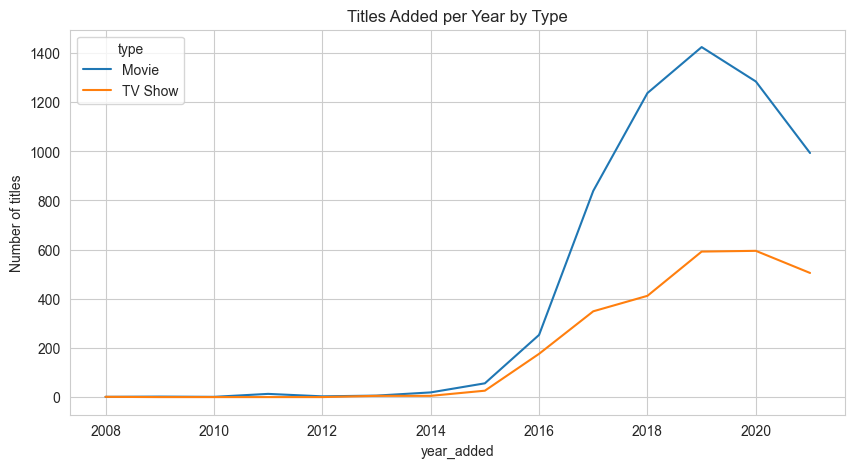

In [2]:
trend = df.dropna(subset=['year_added']).groupby(['year_added', 'type']).size().unstack(fill_value=0)
trend.plot(figsize=(10, 5), title='Titles Added per Year by Type')
plt.ylabel('Number of titles')
plt.savefig('images/type_trend.png', bbox_inches='tight')
plt.show()

## 2. Top genres

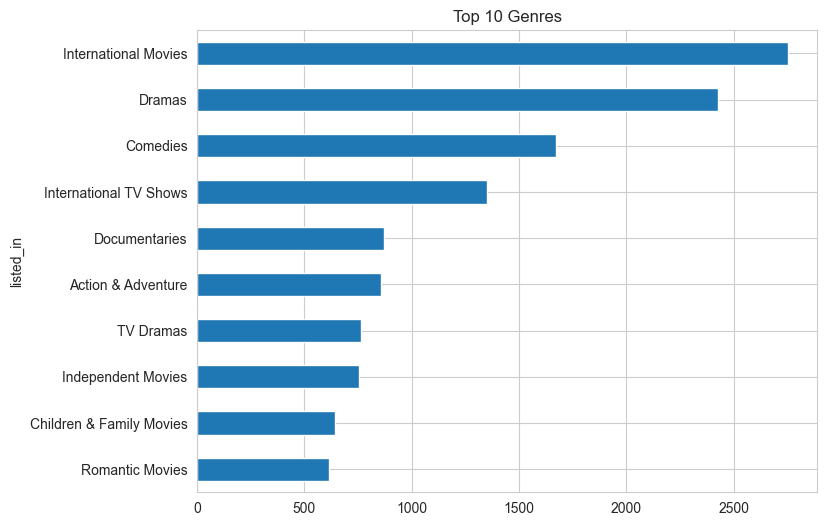

In [3]:
genres = df['listed_in'].dropna().str.split(', ').explode()
top_genres = genres.value_counts().head(10)
top_genres.plot(kind='barh', figsize=(8, 6), title='Top 10 Genres')
plt.gca().invert_yaxis()
plt.savefig('images/top_genres.png', bbox_inches='tight')
plt.show()

## 3. Top countries

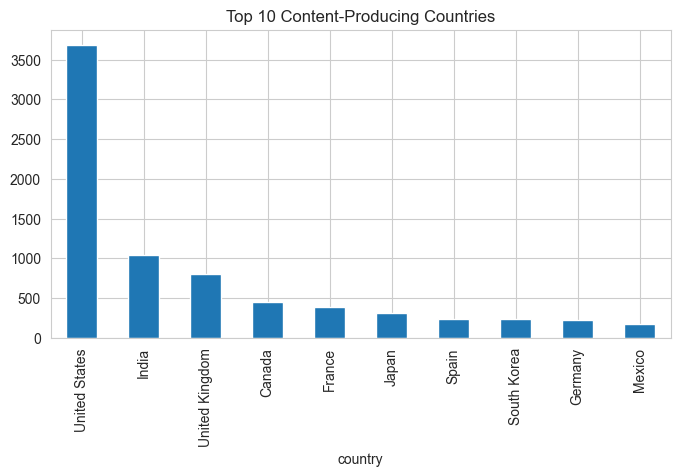

In [4]:
countries = df['country'].dropna().str.split(', ').explode()
top_countries = countries.value_counts().head(10)
top_countries.plot(kind='bar', figsize=(8, 4), title='Top 10 Content-Producing Countries')
plt.savefig('images/top_countries.png', bbox_inches='tight')
plt.show()

## 4. Content rating distribution

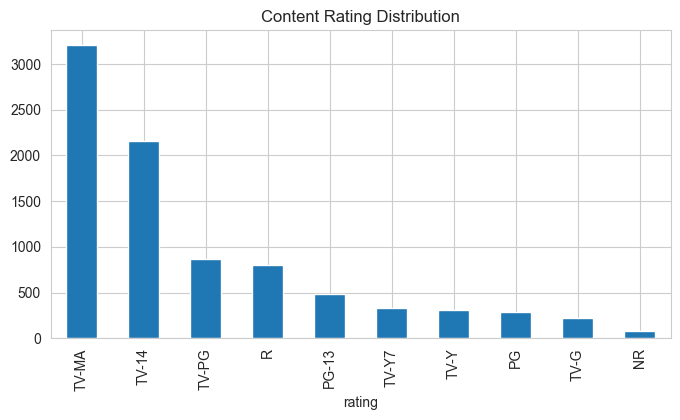

In [5]:
df['rating'].value_counts().head(10).plot(kind='bar', figsize=(8, 4), title='Content Rating Distribution')
plt.savefig('images/rating_distribution.png', bbox_inches='tight')
plt.show()

## 5. Key findings & conclusion

**Findings:**
- Catalog split: 69.6% movies vs. 30.4% TV shows (8,807 titles).
- TV show *additions* share dipped to 25% in 2018 then rose to 33.7% by 2021; movie additions fell ~20% (1,237→993) while TV additions grew ~23% (412→505) over the same window.
- Fastest-growing genres 2018→2021: Anime Series (+82%), TV Action & Adventure (+76%), Kids' TV (+51%) — all series formats.
- Top genres overall: International Movies, Dramas, Comedies. Top countries: US (36.8%), then India (1,046 titles), UK, Canada.
- Ratings skew mature: TV-MA (36.4%) and TV-14 (24.5%) make up ~61% of the catalog.

**Conclusion:**
Netflix's catalog is still majority movies, but growth since 2018 has shifted toward TV — series formats are growing while movie additions decline, and India's strong #2 country position points to continued international investment alongside the format shift.

_(Full detail and business framing in the project [README](./README.md).)_
